### Importing Libaries

In [18]:
import numpy as np
import pandas as pd
import os

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.compose import ColumnTransformer

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

#### Loading Data

In [2]:
path = os.path.join('..', 'Data', 'creditcard.csv')
data = pd.read_csv(path)

In [3]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
data.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
train, test = train_test_split(data, test_size = 0.2, random_state = 42)

In [6]:
y_true = test['Class']
test.drop(['Class'], axis = 1, inplace = True)

#### Preprocessing

In [7]:
X = train.drop(columns = ['Class'])
y = train['Class']

In [8]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
223361,143352.0,1.955041,-0.380783,-0.315013,0.330155,-0.509374,-0.086197,-0.627978,0.035994,1.054560,-0.030441,0.624996,1.691496,1.255790,-0.253266,-0.331695,0.307252,-0.930844,0.651666,0.167987,-0.125390,0.238197,0.968305,0.053208,-0.278602,-0.044999,-0.216780,0.045168,-0.047145,9.99
165061,117173.0,-0.400975,-0.626943,1.555339,-2.017772,-0.107769,0.168310,0.017959,-0.401619,0.040378,0.611115,-1.945070,-0.726597,1.060888,-1.193347,0.631053,-0.160123,-1.630444,2.106866,-1.692780,-0.470372,-0.153485,0.421703,0.113442,-1.004095,-1.176695,0.361924,-0.370469,-0.144792,45.90
238186,149565.0,0.072509,0.820566,-0.561351,-0.709897,1.080399,-0.359429,0.787858,0.117276,-0.131275,-0.638222,0.521931,-0.072768,-1.008237,-0.640249,-0.801946,0.678131,0.044374,0.521919,0.198772,0.012227,-0.314638,-0.872959,0.083391,0.148178,-0.431459,0.119690,0.206395,0.070288,11.99
150562,93670.0,-0.535045,1.014587,1.750679,2.769390,0.500089,1.002270,0.847902,-0.081323,0.371579,0.560595,-0.855437,-4.179628,0.286872,1.271254,-1.011647,1.458600,-0.613260,0.814931,-2.147124,-0.253757,0.063525,0.443431,-0.072754,0.448192,-0.655203,-0.181038,-0.093013,-0.064931,117.44
138452,82655.0,-4.026938,1.897371,-0.429786,-0.029571,-0.855751,-0.480406,-0.435632,1.313760,0.536044,1.221746,0.472626,1.595929,0.777603,0.187685,-1.060579,0.143332,0.007803,-0.055817,0.712695,-0.012320,-0.480691,-0.230369,0.250717,0.066399,0.470787,0.245335,0.286904,-0.322672,25.76


In [9]:
cols = ['Time', 'Amount']

In [10]:
preprocessor = ColumnTransformer(transformers = [
    ('Scaler', StandardScaler(), cols)
],
    remainder = 'passthrough')

In [11]:
X_scaled = preprocessor.fit_transform(X)
test = preprocessor.transform(test)

In [20]:
sm = SMOTE(random_state = 42)
X_resampled, y_resampled = sm.fit_resample(X_scaled, y)

In [12]:
models = {
    'LogisticRegression': LogisticRegression(class_weight = 'balanced'),
    'RandomForestClassifier': RandomForestClassifier(class_weight = 'balanced'),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'XGBClassifier': XGBClassifier(),
    'CatBooostClassifier': CatBoostClassifier(verbose = False)
}

In [21]:
for i in range(len(models)):
    model = list(models.values())[i]

    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(test)
    y_prob = model.predict_proba(test)[:, 1]

    print('*' * 20)
    print(f'Model: {list(models.keys())[i]}')
    print(f'Precision: {precision_score(y_true, y_pred)}')    
    print(f'Recall Score: {recall_score(y_true, y_pred)}')    
    print(f'F1 Score: {f1_score(y_true, y_pred)}')    
    print(f'Confusion Matrix: \n{confusion_matrix(y_true, y_pred)}')
    print(f'ROC-AUC: {roc_auc_score(y_true, y_prob)}')

********************
Model: LogisticRegression
Precision: 0.059322033898305086
Recall Score: 0.9285714285714286
F1 Score: 0.11151960784313726
Confusion Matrix: 
[[55421  1443]
 [    7    91]]
ROC-AUC: 0.9786340376752839
********************
Model: RandomForestClassifier
Precision: 0.9101123595505618
Recall Score: 0.826530612244898
F1 Score: 0.8663101604278075
Confusion Matrix: 
[[56856     8]
 [   17    81]]
ROC-AUC: 0.9693351770927842
********************
Model: DecisionTreeClassifier
Precision: 0.41899441340782123
Recall Score: 0.7653061224489796
F1 Score: 0.5415162454873647
Confusion Matrix: 
[[56760   104]
 [   23    75]]
ROC-AUC: 0.8817385986471122
********************
Model: XGBClassifier
Precision: 0.7545454545454545
Recall Score: 0.8469387755102041
F1 Score: 0.7980769230769231
Confusion Matrix: 
[[56837    27]
 [   15    83]]
ROC-AUC: 0.9884269162082391
********************
Model: CatBooostClassifier
Precision: 0.6013986013986014
Recall Score: 0.8775510204081632
F1 Score: 0.713

#### Feature importance

In [14]:
cb = CatBoostClassifier(verbose = False)
cb.fit(X_scaled, y)

CatBoostClassifier(verbose=False)

<Axes: >

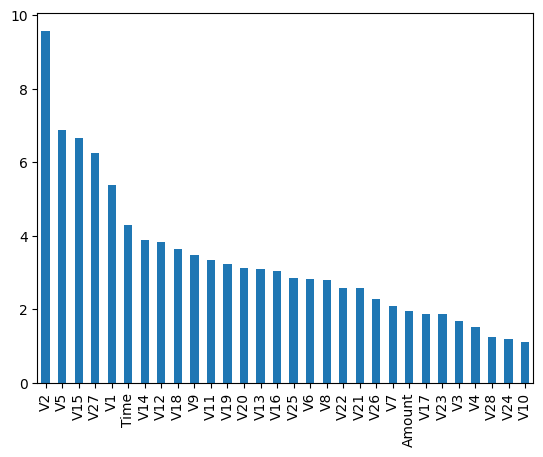

In [15]:
feature_names = X.columns
imp_features = pd.Series(cb.get_feature_importance(), index = feature_names)

imp_features.sort_values(ascending = False).plot(kind = 'bar')